In [2]:
import pandas as pd 
filepath = "C:\\Users\александр\PycharmProjects\RecSys\datasets\home-credit-default-risk\\application_train.csv"
df_train = pd.read_csv(filepath)
import pandas as pd
import numpy as np

# Для предобработки данных
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Для PCA
from sklearn.decomposition import PCA

# Для отбора признаков
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
# Обработка пропущенных значений (пример: заполнение медианой для численных, модой для категориальных)
for column in df_train.columns:
    if df_train[column].dtype == 'object':
        df_train[column].fillna(df_train[column].mode()[0], inplace=True)
    else:
        df_train[column].fillna(df_train[column].median(), inplace=True)

# Кодирование категориальных признаков
categorical_cols = df_train.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    label_encoders[col] = le

# Разделение на признаки и целевую переменную
X = df_train.drop('TARGET', axis=1)  # Предполагая, что целевая переменная называется 'TARGET'
y = df_train['TARGET']

# Масштабирование численных признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Инициализация PCA. Например, сохранить 95% дисперсии
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Количество компонент после PCA: {pca.n_components_}")
# Выбор 20 лучших признаков на основе ANOVA F-теста
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X_scaled, y)

# Получение названий выбранных признаков
selected_features = X.columns[selector.get_support()]
print("Выбранные признаки:", selected_features)
# Инициализация классификатора
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучение классификатора
clf.fit(X_scaled, y)

# Использование важности признаков для отбора
model = SelectFromModel(clf, prefit=True, threshold='median')  # Можно настроить threshold
X_model_selected = model.transform(X_scaled)

# Получение названий выбранных признаков
selected_features_model = X.columns[model.get_support()]
print("Выбранные признаки моделью:", selected_features_model)


C:\Users\александр\AppData\Local\Temp\ipykernel_5516\3854138692.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[column].fillna(df_train[column].median(), inplace=True)
C:\Users\александр\AppData\Local\Temp\ipykernel_5516\3854138692.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Количество компонент после PCA: 73
Выбранные признаки: Index(['CODE_GENDER', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI',
       'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_3'],
      dtype='object')
Выбранные признаки моделью: Index(['SK_ID_CURR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'WEEKDAY_APPR_PROCESS_STAR

C:\Users\александр\AppData\Local\Temp\ipykernel_5516\3714993388.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[column].fillna(df_train[column].median(), inplace=True)
C:\Users\александр\AppData\Local\Temp\ipykernel_5516\3714993388.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Количество компонент после PCA: 73
Индексы выбранных признаков (SelectKBest): [ 0  2  3  4  5 10 11 12 13 17 18 21 24 25 26 47 48 61 62 64]
Индексы выбранных признаков (Model-based Select): [ 0  2  3  4  5  7 10 11 12 13 17 18 19 21 23 24 25 39 40 47 48 50 55 58
 59 60 61 62 63 64 65 66 67 68 69 70 71]
ROC AUC для модели на PCA-признаках: 0.6754
ROC AUC для модели на SelectKBest-признаках: 0.6894
ROC AUC для модели на Model-based Select-признаках: 0.6815


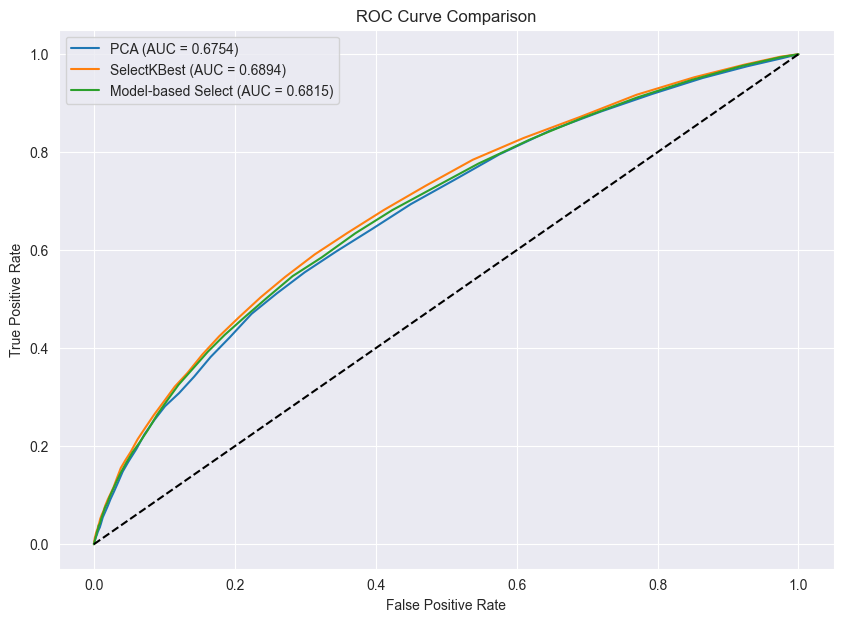

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
filepath = "C:\\Users\\александр\\PycharmProjects\\RecSys\\datasets\\home-credit-default-risk\\application_train.csv"
df_train = pd.read_csv(filepath)

# 2. Предобработка данных

# 2.1 Обработка пропущенных значений
for column in df_train.columns:
    if df_train[column].dtype == 'object':
        df_train[column].fillna(df_train[column].mode()[0], inplace=True)
    else:
        df_train[column].fillna(df_train[column].median(), inplace=True)

# 2.2 Кодирование категориальных признаков
categorical_cols = df_train.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    label_encoders[col] = le

# 2.3 Разделение на признаки и целевую переменную
X = df_train.drop('TARGET', axis=1)
y = df_train['TARGET']

# 2.4 Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Применение PCA
pca = PCA(n_components=0.95, random_state=42)  # Сохраняем 95% дисперсии
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"Количество компонент после PCA: {pca.n_components_}")

# 5. Отбор признаков

# 5.1 Статистический отбор признаков с помощью SelectKBest
k_best = 20  # Выберите количество признаков по необходимости
selector_kbest = SelectKBest(score_func=f_classif, k=k_best)
X_train_kbest = selector_kbest.fit_transform(X_train_pca, y_train)
X_test_kbest = selector_kbest.transform(X_test_pca)
selected_features_kbest = selector_kbest.get_support(indices=True)
print(f"Индексы выбранных признаков (SelectKBest): {selected_features_kbest}")

# 5.2 Отбор признаков с использованием модели (Random Forest)
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_pca, y_train)

# Используем SelectFromModel для отбора признаков
selector_model = SelectFromModel(clf_rf, prefit=True, threshold='median')
X_train_model = selector_model.transform(X_train_pca)
X_test_model = selector_model.transform(X_test_pca)
selected_features_model = selector_model.get_support(indices=True)
print(f"Индексы выбранных признаков (Model-based Select): {selected_features_model}")

# 6. Обучение моделей

# 6.1 Модель на PCA-признаках
clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict_proba(X_test_pca)[:, 1]
auc_pca = roc_auc_score(y_test, y_pred_pca)
print(f"ROC AUC для модели на PCA-признаках: {auc_pca:.4f}")

# 6.2 Модель на признаках после SelectKBest
clf_kbest = RandomForestClassifier(n_estimators=100, random_state=42)
clf_kbest.fit(X_train_kbest, y_train)
y_pred_kbest = clf_kbest.predict_proba(X_test_kbest)[:, 1]
auc_kbest = roc_auc_score(y_test, y_pred_kbest)
print(f"ROC AUC для модели на SelectKBest-признаках: {auc_kbest:.4f}")

# 6.3 Модель на признаках после Model-based Select
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_model, y_train)
y_pred_model = clf_model.predict_proba(X_test_model)[:, 1]
auc_model = roc_auc_score(y_test, y_pred_model)
print(f"ROC AUC для модели на Model-based Select-признаках: {auc_model:.4f}")

# 7. Визуализация ROC-кривых
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_pred_pca)
fpr_kbest, tpr_kbest, _ = roc_curve(y_test, y_pred_kbest)
fpr_model, tpr_model, _ = roc_curve(y_test, y_pred_model)

plt.figure(figsize=(10, 7))
plt.plot(fpr_pca, tpr_pca, label=f'PCA (AUC = {auc_pca:.4f})')
plt.plot(fpr_kbest, tpr_kbest, label=f'SelectKBest (AUC = {auc_kbest:.4f})')
plt.plot(fpr_model, tpr_model, label=f'Model-based Select (AUC = {auc_model:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Диагональ
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()
